### Model Neurons Overlap

In [10]:
import json 

def check_overlap(file_paths, label):
    neurons_list = []
    for file_path in file_paths:
        with open(file_path, "r") as f:
            neurons_list.append(json.load(f)["neurons"])
    
    for top_n in [0.4]:  # , 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9
        sum_overlap = []
        for layer_nb in range(4, 27):
            top_neurons_all = []
            for neurons in neurons_list:
                layer_neurons = neurons[layer_nb]
                n = int(len(layer_neurons) * top_n)
                top_neurons_all.append(set(layer_neurons[:n]))
            common_indices = set.intersection(*top_neurons_all)
            avg_set_size = sum(len(s) for s in top_neurons_all) / len(top_neurons_all)
            overlap_percentage = (len(common_indices) / avg_set_size) * 100 if avg_set_size > 0 else 0
            sum_overlap.append(overlap_percentage)
        print(f"{label}: {sum(sum_overlap) / len(sum_overlap):.2f}%")
        

check_overlap(["insights_files/neurons_files/wmt16-de-en/all.json", "insights_files/neurons_files/piqa/all.json"], "wmt16-de-en vs piqa")
check_overlap(["insights_files/neurons_files/wmt16-de-en/all.json", "insights_files/neurons_files/cnn_dailymail/all.json"], "wmt16-de-en vs cnn_dailymail")
check_overlap(["insights_files/neurons_files/piqa/all.json", "insights_files/neurons_files/cnn_dailymail/all.json"], "piqa vs cnn_dailymail")

# Check overlap between all 3
check_overlap(["insights_files/neurons_files/piqa/all.json",
               "insights_files/neurons_files/cnn_dailymail/all.json",
               "insights_files/neurons_files/wmt16-de-en/all.json"
               ], "All three datasets")

wmt16-de-en vs piqa: 67.94%
wmt16-de-en vs cnn_dailymail: 72.86%
piqa vs cnn_dailymail: 71.85%
All three datasets: 59.90%


### Prove that neurons overlap exist for each different task

In [11]:
import json

datasets_common_indices = []
for dataset in ["piqa", "wmt16-de-en", "cnn_dailymail"]:
    neurons = []
    for i in range(0, 10):
        file_path = f"./insights_files/neurons_files/{dataset}/{i}.json"
        with open(file_path, "r") as f:
            n = json.load(f)["neurons"]
            neurons.append(n)
        
    for top_n in [0.4]: # , 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9
        sum_overlap = []
        for layer_nb in range(4, 27):
            top_neurons_all = []
            for neurons_file in neurons:
                file_layer_neurons = neurons_file[layer_nb]
                
                n = int(len(file_layer_neurons) * top_n)
                first_n_file = set(file_layer_neurons[:n])
                top_neurons_all.append(first_n_file)
                
            common_indices = set.intersection(*top_neurons_all)
            datasets_common_indices.append(common_indices)
            avg_set_size = sum(len(s) for s in top_neurons_all) / len(top_neurons_all)
            overlap_percentage = (len(common_indices) / avg_set_size) * 100
            
            sum_overlap.append(overlap_percentage)
            # print(f"Layer {layer_nb}: {overlap_percentage:.2f}% overlap in first {int(top_n*100)}%")
            
        print(f"{dataset}: Avg in top {int(top_n*100)}%: {sum(sum_overlap) / len(sum_overlap)}")

piqa: Avg in top 40%: 58.48595848595851
wmt16-de-en: Avg in top 40%: 65.13510643945426
cnn_dailymail: Avg in top 40%: 69.58247066942718


### Prove that they are different for each task

In [12]:
new_set = datasets_common_indices[0] & datasets_common_indices[1]
print(len(new_set) / ((len(datasets_common_indices[0]) + len(datasets_common_indices[1])) / 2))

new_set = datasets_common_indices[0] & datasets_common_indices[2]
print(len(new_set) / ((len(datasets_common_indices[0]) + len(datasets_common_indices[2])) / 2))

new_set = datasets_common_indices[3] & datasets_common_indices[2]
print(len(new_set) / ((len(datasets_common_indices[3]) + len(datasets_common_indices[2])) / 2))

0.22729715206878023
0.2364917776037588
0.2438153532262178


# Draw Results

/tmp/ipykernel_929076/4171675154.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(task_specific.keys()), y=list(task_specific.values()), palette="Blues_d")


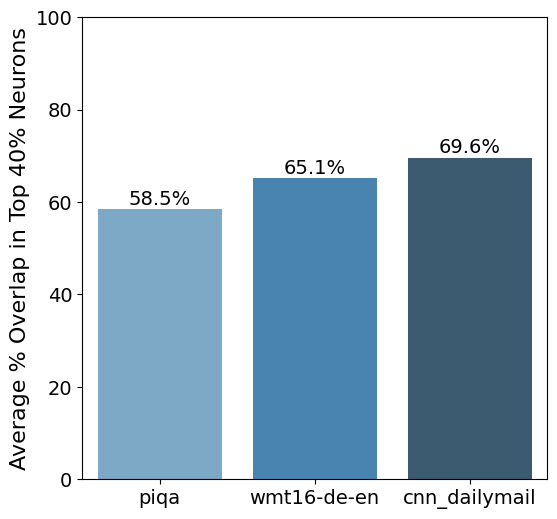

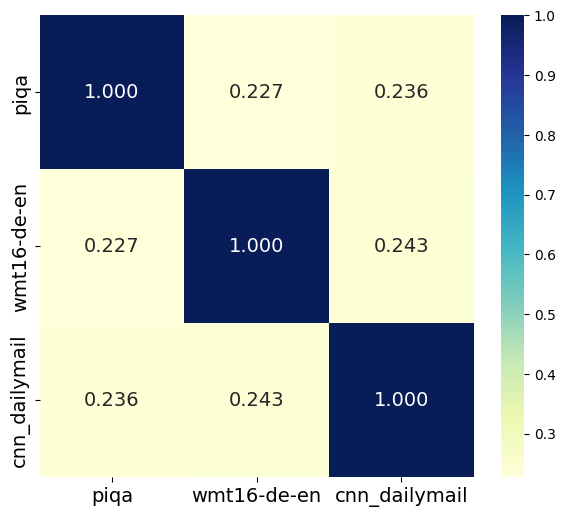

/tmp/ipykernel_929076/4171675154.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


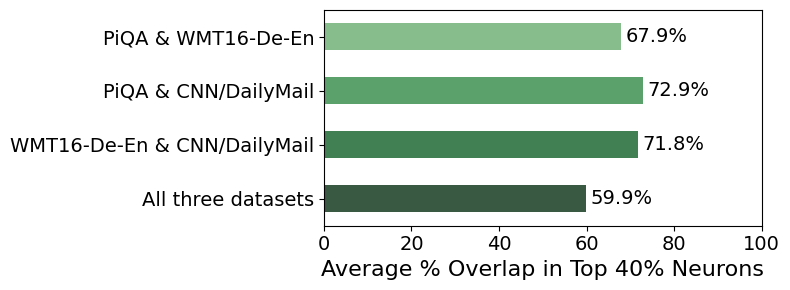

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# -------------------------------
# 1. Task-specific overlaps
# -------------------------------
task_specific = {
    "piqa": 58.485,
    "wmt16-de-en": 65.135,
    "cnn_dailymail": 69.582
}

plt.figure(figsize=(6, 6))
sns.barplot(x=list(task_specific.keys()), y=list(task_specific.values()), palette="Blues_d")
plt.ylabel("Average % Overlap in Top 40% Neurons", fontsize=16)
# plt.title("Task-Specific Neuron Consistency (Intra-Task)")
plt.ylim(0, 100)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
for i, v in enumerate(task_specific.values()):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=14)
plt.show()


# -------------------------------
# 2. Cross-task overlaps (Task-specific neurons differ)
# -------------------------------
cross_task = {
    "piqa & wmt16-de-en": 0.227,
    "piqa & cnn_dailymail": 0.236,
    "wmt16-de-en & cnn_dailymail": 0.243
}

# Convert into heatmap matrix
tasks = ["piqa", "wmt16-de-en", "cnn_dailymail"]
matrix = np.array([
    [1.0, cross_task["piqa & wmt16-de-en"], cross_task["piqa & cnn_dailymail"]],
    [cross_task["piqa & wmt16-de-en"], 1.0, cross_task["wmt16-de-en & cnn_dailymail"]],
    [cross_task["piqa & cnn_dailymail"], cross_task["wmt16-de-en & cnn_dailymail"], 1.0]
])

plt.figure(figsize=(7, 6))
sns.heatmap(matrix, xticklabels=tasks, yticklabels=tasks, annot=True, cmap="YlGnBu", fmt=".3f", annot_kws={"size": 14})
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# plt.title("Cross-Task Neuron Overlap (Task-Specificity)")
plt.show()


# -------------------------------
# 3. Model neurons (general overlap across tasks)
# -------------------------------
model_neurons = {
    "PiQA & WMT16-De-En": 67.94,
    "PiQA & CNN/DailyMail": 72.86,
    "WMT16-De-En & CNN/DailyMail": 71.85,
    "All three datasets": 59.90
}

plt.figure(figsize=(8, 3))
sns.barplot(
    y=list(model_neurons.keys()),
    x=list(model_neurons.values()),
    palette="Greens_d",
    orient="h",
    width=0.5,           # Reduce bar width
    dodge=False          # Reduce gap between bars
)
plt.xlabel("Average % Overlap in Top 40% Neurons", fontsize=16)
plt.xlim(0, 100)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
for i, (label, v) in enumerate(model_neurons.items()):
    plt.text(v + 1, i, f"{v:.1f}%", va="center", fontsize=14)
plt.tight_layout()      # Further reduce gaps around plot
plt.show()